# NB10: *P. aeruginosa* Lung Adaptation and Disease-Associated Variation

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Characterize what makes lung/airway PA variants special compared to non-lung PA, what distinguishes lung PA from each other, and which metabolic themes associate with sicker vs. less sick lungs.

## Questions
1. Among 6,760 PA genomes in the pangenome, what is special about lung/airway isolates?
2. Within lung PA, what are the main axes of variation (GapMind pathways, functional categories)?
3. From PROTECT patient data: which PA metabolic pathways are more active in sicker patients (acute exacerbation) vs stable patients?

**Why this matters for formulation design**: Understanding PA's lung-specific metabolic adaptations reveals which substrates are most critical for competitive exclusion in the actual disease context, and whether PA metabolic variability between patients requires formulation customization.

**Requires**: BERDL Spark + local PROTECT data

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

PA_CLADE = 's__Pseudomonas_aeruginosa--RS_GCF_001457615.1'
print(f'Spark ready. PA clade: {PA_CLADE}')

Spark ready. PA clade: s__Pseudomonas_aeruginosa--RS_GCF_001457615.1


## 1. Classify PA Genomes by Isolation Source

6,760 PA genomes in the pangenome; 5,199 have isolation_source metadata. Classify into: Lung/Respiratory, CF-specific, Clinical/Other, and Environmental.

In [2]:
# Get all PA isolation sources
pa_env = spark.sql(f"""
    SELECT g.genome_id, n.content AS isolation_source
    FROM kbase_ke_pangenome.genome g
    JOIN kbase_ke_pangenome.ncbi_env n ON g.ncbi_biosample_id = n.accession
    WHERE g.gtdb_species_clade_id = '{PA_CLADE}'
      AND n.harmonized_name = 'isolation_source'
""").toPandas()

print(f'PA genomes with isolation source: {pa_env.genome_id.nunique()}')

# Classify
def classify_pa_source(text):
    if pd.isna(text): return 'Unknown'
    t = str(text).lower()
    # CF-specific (most informative category)
    if 'cystic fibrosis' in t or 'cf ' in t or 'cf_' in t:
        return 'CF patient'
    # Lung/respiratory (non-CF)
    if any(x in t for x in ['sputum', 'lung', 'respiratory', 'bronch', 'trachea', 
                             'bal', 'bronchoalveolar', 'pneumonia', 'pulmonary']):
        return 'Lung/Respiratory'
    # Upper airway
    if any(x in t for x in ['throat', 'pharyn', 'nasal', 'sinus', 'ear', 'otitis']):
        return 'Upper Airway'
    # Other clinical
    if any(x in t for x in ['blood', 'wound', 'burn', 'urine', 'urinary', 'eye', 'cornea',
                             'abscess', 'hospital', 'ward', 'icu', 'clinical', 'patient',
                             'infection', 'feces']):
        return 'Other Clinical'
    # Environmental
    if any(x in t for x in ['soil', 'water', 'river', 'marine', 'sediment', 'plant',
                             'rhizo', 'compost', 'drain', 'sink', 'shower']):
        return 'Environmental'
    if 'missing' in t or 'not applicable' in t or 'not collected' in t:
        return 'Unknown'
    return 'Other'

pa_env['category'] = pa_env.isolation_source.apply(classify_pa_source)
cat_counts = pa_env.groupby('category')['genome_id'].nunique().sort_values(ascending=False)
print(f'\nPA genome categories:')
total = pa_env.genome_id.nunique()
for cat, n in cat_counts.items():
    print(f'  {cat}: {n} ({n/total:.0%})')

# Define the key comparison groups
lung_ids = pa_env[pa_env.category.isin(['Lung/Respiratory', 'CF patient'])].genome_id.unique()
env_ids = pa_env[pa_env.category == 'Environmental'].genome_id.unique()
other_clinical = pa_env[pa_env.category == 'Other Clinical'].genome_id.unique()
print(f'\nKey groups: Lung/CF={len(lung_ids)}, Environmental={len(env_ids)}, Other Clinical={len(other_clinical)}')

PA genomes with isolation source: 5199

PA genome categories:
  Other Clinical: 1731 (33%)
  Lung/Respiratory: 1505 (29%)
  Other: 706 (14%)
  Unknown: 430 (8%)
  Environmental: 370 (7%)
  CF patient: 291 (6%)
  Upper Airway: 166 (3%)

Key groups: Lung/CF=1796, Environmental=370, Other Clinical=1731


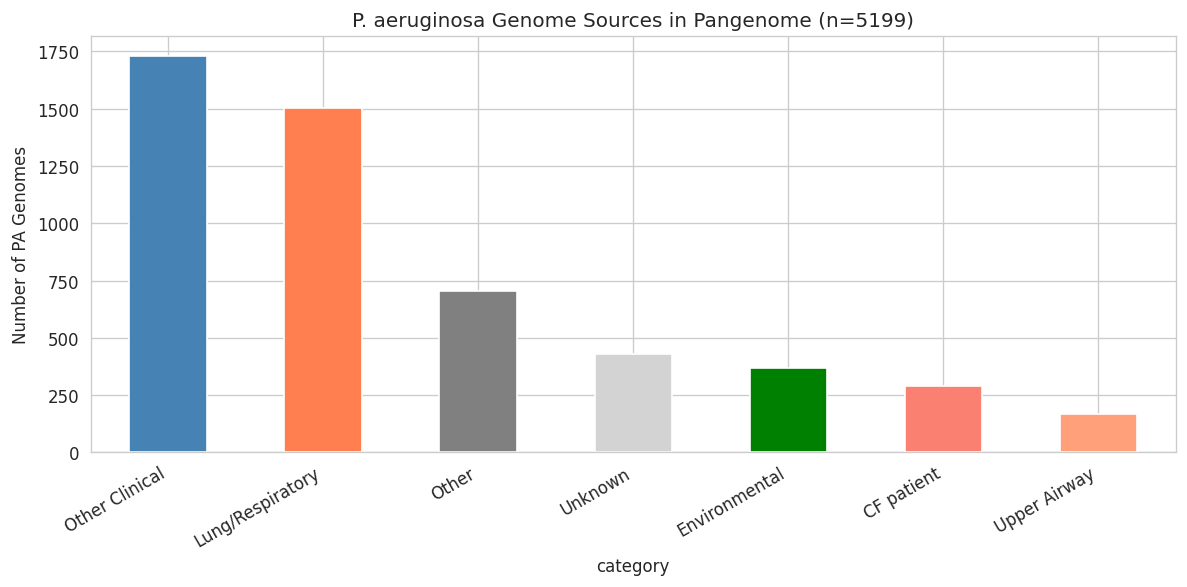

In [3]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'CF patient': 'salmon', 'Lung/Respiratory': 'coral', 'Upper Airway': 'lightsalmon',
          'Other Clinical': 'steelblue', 'Environmental': 'green', 'Other': 'grey', 'Unknown': 'lightgrey'}
cat_counts.plot.bar(ax=ax, color=[colors.get(c, 'grey') for c in cat_counts.index])
ax.set_ylabel('Number of PA Genomes')
ax.set_title(f'P. aeruginosa Genome Sources in Pangenome (n={total})')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGS / '10_pa_genome_sources.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Lung PA vs Non-Lung PA: GapMind Metabolic Comparison

Do lung/CF PA genomes have different metabolic pathway profiles than environmental or other-clinical PA? This reveals lung-specific metabolic adaptations.

In [4]:
# Get per-genome GapMind pathway scores for ALL PA genomes
# This is a large query — PA has 6,760 genomes × ~80 pathways
print('Querying GapMind for all PA genomes (may take a few minutes)...')
pa_gm = spark.sql(f"""
    WITH scored AS (
        SELECT genome_id, pathway, metabolic_category,
            CASE score_category
                WHEN 'complete' THEN 5 WHEN 'likely_complete' THEN 4
                WHEN 'steps_missing_low' THEN 3 WHEN 'steps_missing_medium' THEN 2
                WHEN 'not_present' THEN 1 ELSE 0
            END AS score_val
        FROM kbase_ke_pangenome.gapmind_pathways
        WHERE clade_name = '{PA_CLADE}'
    )
    SELECT genome_id, pathway, metabolic_category,
        MAX(score_val) AS best_score
    FROM scored
    GROUP BY genome_id, pathway, metabolic_category
""").toPandas()

print(f'PA GapMind data: {len(pa_gm)} rows, {pa_gm.genome_id.nunique()} genomes, {pa_gm.pathway.nunique()} pathways')

# Tag with source category (strip RS_/GB_ prefix for GapMind IDs)
pa_env_map = pa_env.drop_duplicates('genome_id').set_index('genome_id')['category']
# GapMind IDs lack prefix
prefix_map = {}
for gid in pa_env_map.index:
    stripped = gid[3:] if gid.startswith(('RS_', 'GB_')) else gid
    prefix_map[stripped] = pa_env_map[gid]

pa_gm['source_category'] = pa_gm.genome_id.map(prefix_map).fillna('Unknown')
print(f'\nSource mapping coverage: {pa_gm.source_category.ne("Unknown").mean():.0%}')

Querying GapMind for all PA genomes (may take a few minutes)...


PA GapMind data: 540800 rows, 6760 genomes, 80 pathways

Source mapping coverage: 71%


In [5]:
# Compare pathway completeness: Lung/CF vs Environmental vs Other Clinical
lung_cf = pa_gm[pa_gm.source_category.isin(['Lung/Respiratory', 'CF patient'])]
environ = pa_gm[pa_gm.source_category == 'Environmental']
other_clin = pa_gm[pa_gm.source_category == 'Other Clinical']

# Mean pathway score per group
lung_mean = lung_cf.groupby('pathway')['best_score'].mean()
env_mean = environ.groupby('pathway')['best_score'].mean()
clin_mean = other_clin.groupby('pathway')['best_score'].mean()

# Difference: lung vs environmental
diff_env = (lung_mean - env_mean).dropna().sort_values()
diff_clin = (lung_mean - clin_mean).dropna().sort_values()

print('=== Pathways MORE complete in Lung/CF PA vs Environmental PA ===')
print(diff_env.tail(10).round(3).to_string())
print(f'\n=== Pathways LESS complete in Lung/CF PA vs Environmental PA ===')
print(diff_env.head(10).round(3).to_string())

print(f'\n=== Pathways MORE complete in Lung/CF PA vs Other Clinical PA ===')
print(diff_clin.tail(10).round(3).to_string())
print(f'\n=== Pathways LESS complete in Lung/CF PA vs Other Clinical PA ===')
print(diff_clin.head(10).round(3).to_string())

=== Pathways MORE complete in Lung/CF PA vs Environmental PA ===
pathway
phe            0.000
pro            0.000
deoxyribose    0.001
threonine      0.002
tryptophan     0.002
pyruvate       0.006
putrescine     0.006
ser            0.010
ribose         0.015
acetate        0.019

=== Pathways LESS complete in Lung/CF PA vs Environmental PA ===
pathway
mannitol        -0.251
gluconate       -0.235
sorbitol        -0.185
arabinose       -0.079
NAG             -0.046
fructose        -0.041
maltose         -0.038
glucose         -0.038
glucosamine     -0.035
deoxyribonate   -0.033

=== Pathways MORE complete in Lung/CF PA vs Other Clinical PA ===
pathway
pro            0.000
chorismate     0.001
trp            0.001
cys            0.002
lys            0.002
thr            0.002
ser            0.002
arg            0.004
fructose       0.018
glucosamine    0.022

=== Pathways LESS complete in Lung/CF PA vs Other Clinical PA ===
pathway
mannitol        -0.245
gluconate       -0.242
sorbito

In [6]:
# Statistical test: which pathways differ significantly between lung and non-lung?
non_lung = pa_gm[~pa_gm.source_category.isin(['Lung/Respiratory', 'CF patient', 'Unknown'])]

sig_results = []
for pathway in pa_gm.pathway.unique():
    lung_scores = lung_cf[lung_cf.pathway == pathway]['best_score']
    nonlung_scores = non_lung[non_lung.pathway == pathway]['best_score']
    if len(lung_scores) < 10 or len(nonlung_scores) < 10:
        continue
    u_stat, p_val = stats.mannwhitneyu(lung_scores, nonlung_scores, alternative='two-sided')
    sig_results.append({
        'pathway': pathway,
        'lung_mean': lung_scores.mean(),
        'nonlung_mean': nonlung_scores.mean(),
        'diff': lung_scores.mean() - nonlung_scores.mean(),
        'p_value': p_val,
        'n_lung': len(lung_scores),
        'n_nonlung': len(nonlung_scores)
    })

sig_df = pd.DataFrame(sig_results)
# BH-FDR correction
from statsmodels.stats.multitest import multipletests
sig_df['q_value'] = multipletests(sig_df.p_value, method='fdr_bh')[1]
sig_df = sig_df.sort_values('q_value')

print(f'Pathways tested: {len(sig_df)}')
print(f'Significant at FDR < 0.05: {(sig_df.q_value < 0.05).sum()}')
print(f'\nTop significant pathways (lung vs non-lung):')
print(sig_df[sig_df.q_value < 0.05][['pathway','lung_mean','nonlung_mean','diff','q_value']].round(4).to_string(index=False))

Pathways tested: 80
Significant at FDR < 0.05: 7

Top significant pathways (lung vs non-lung):
  pathway  lung_mean  nonlung_mean    diff  q_value
 sorbitol     3.7634        3.9284 -0.1650   0.0000
gluconate     4.6570        4.8416 -0.1846   0.0000
 mannitol     3.6431        3.8470 -0.2039   0.0000
D-lactate     4.8864        4.9448 -0.0584   0.0064
threonine     4.9694        4.9832 -0.0138   0.0064
 rhamnose     3.0033        3.0249 -0.0215   0.0098
   fucose     3.0033        3.0249 -0.0215   0.0098


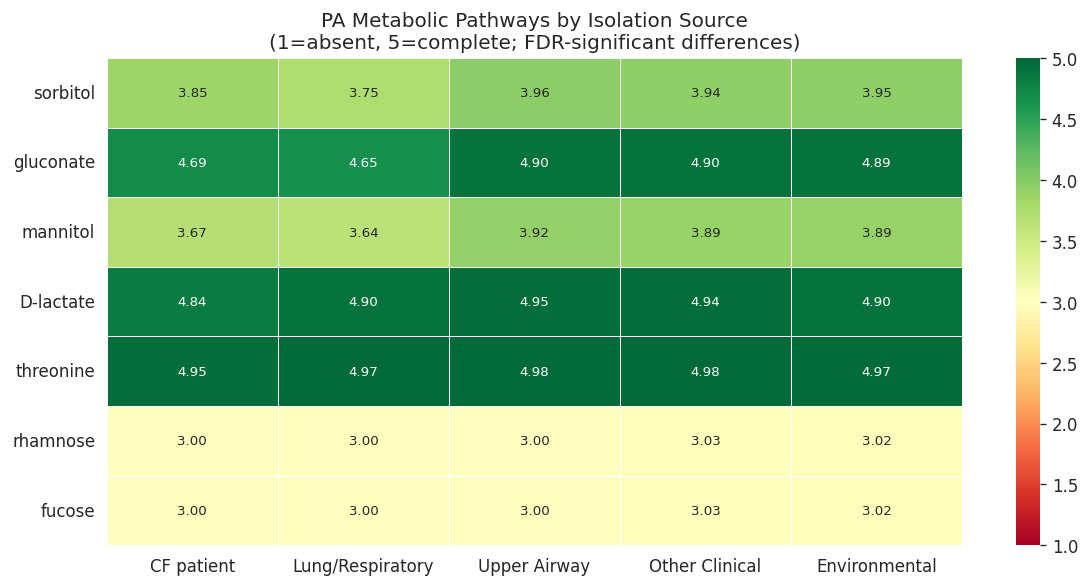

In [7]:
# Heatmap: pathways that differ between source categories
top_diff = sig_df[sig_df.q_value < 0.1].pathway.tolist()
if len(top_diff) < 5:
    top_diff = sig_df.nsmallest(15, 'q_value').pathway.tolist()

# Mean scores per category for top pathways
categories = ['CF patient', 'Lung/Respiratory', 'Upper Airway', 'Other Clinical', 'Environmental']
heatmap_data = {}
for cat in categories:
    cat_data = pa_gm[pa_gm.source_category == cat]
    if len(cat_data) > 0:
        heatmap_data[cat] = cat_data.groupby('pathway')['best_score'].mean()

hm = pd.DataFrame(heatmap_data).loc[top_diff]

fig, ax = plt.subplots(figsize=(10, max(5, len(top_diff) * 0.4)))
sns.heatmap(hm, cmap='RdYlGn', vmin=1, vmax=5, linewidths=0.5, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 8})
ax.set_title('PA Metabolic Pathways by Isolation Source\n(1=absent, 5=complete; FDR-significant differences)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / '10_pa_lung_vs_nonlung_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Within-Lung PA Diversity: Main Axes of Variation

Among the lung/CF PA genomes, what are the main themes of metabolic variation? PCA on GapMind profiles reveals the principal axes.

In [8]:
# PCA on lung PA GapMind profiles
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Pivot to genome x pathway matrix
lung_pivot = lung_cf.pivot_table(index='genome_id', columns='pathway', values='best_score').fillna(0)
print(f'Lung PA pathway matrix: {lung_pivot.shape[0]} genomes x {lung_pivot.shape[1]} pathways')

# PCA
scaler = StandardScaler()
X = scaler.fit_transform(lung_pivot.values)
pca = PCA(n_components=min(10, X.shape[1]))
coords = pca.fit_transform(X)

print(f'\nPCA variance explained:')
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f'  PC{i+1}: {pca.explained_variance_ratio_[i]:.1%}')
print(f'  Cumulative (5 PCs): {pca.explained_variance_ratio_[:5].sum():.1%}')

# Top loading pathways per PC
for pc_idx in range(min(3, len(pca.components_))):
    loadings = pd.Series(pca.components_[pc_idx], index=lung_pivot.columns)
    top_pos = loadings.nlargest(5)
    top_neg = loadings.nsmallest(5)
    print(f'\nPC{pc_idx+1} top loadings:')
    print(f'  Positive: {dict(top_pos.round(3))}')
    print(f'  Negative: {dict(top_neg.round(3))}')

Lung PA pathway matrix: 1796 genomes x 80 pathways

PCA variance explained:
  PC1: 67.0%
  PC2: 3.5%
  PC3: 2.8%
  PC4: 2.7%
  PC5: 2.6%
  Cumulative (5 PCs): 78.7%

PC1 top loadings:
  Positive: {'aspartate': np.float64(0.142), 'succinate': np.float64(0.142), 'valine': np.float64(0.142), '2-oxoglutarate': np.float64(0.142), 'D-alanine': np.float64(0.142)}
  Negative: {'arg': np.float64(-0.003), 'lys': np.float64(-0.001), 'thr': np.float64(-0.001), 'pro': np.float64(-0.001), 'val': np.float64(-0.001)}

PC2 top loadings:
  Positive: {'thymidine': np.float64(0.529), 'deoxyinosine': np.float64(0.529), 'acetate': np.float64(0.344), 'putrescine': np.float64(0.273), 'pyruvate': np.float64(0.186)}
  Negative: {'his': np.float64(-0.141), 'galactose': np.float64(-0.121), 'rhamnose': np.float64(-0.118), 'fucose': np.float64(-0.118), 'lactose': np.float64(-0.117)}

PC3 top loadings:
  Positive: {'val': np.float64(0.641), 'leu': np.float64(0.641), 'acetate': np.float64(0.125), 'putrescine': np.flo

Category mapping: {'Lung/Respiratory': 1505, 'CF patient': 291}


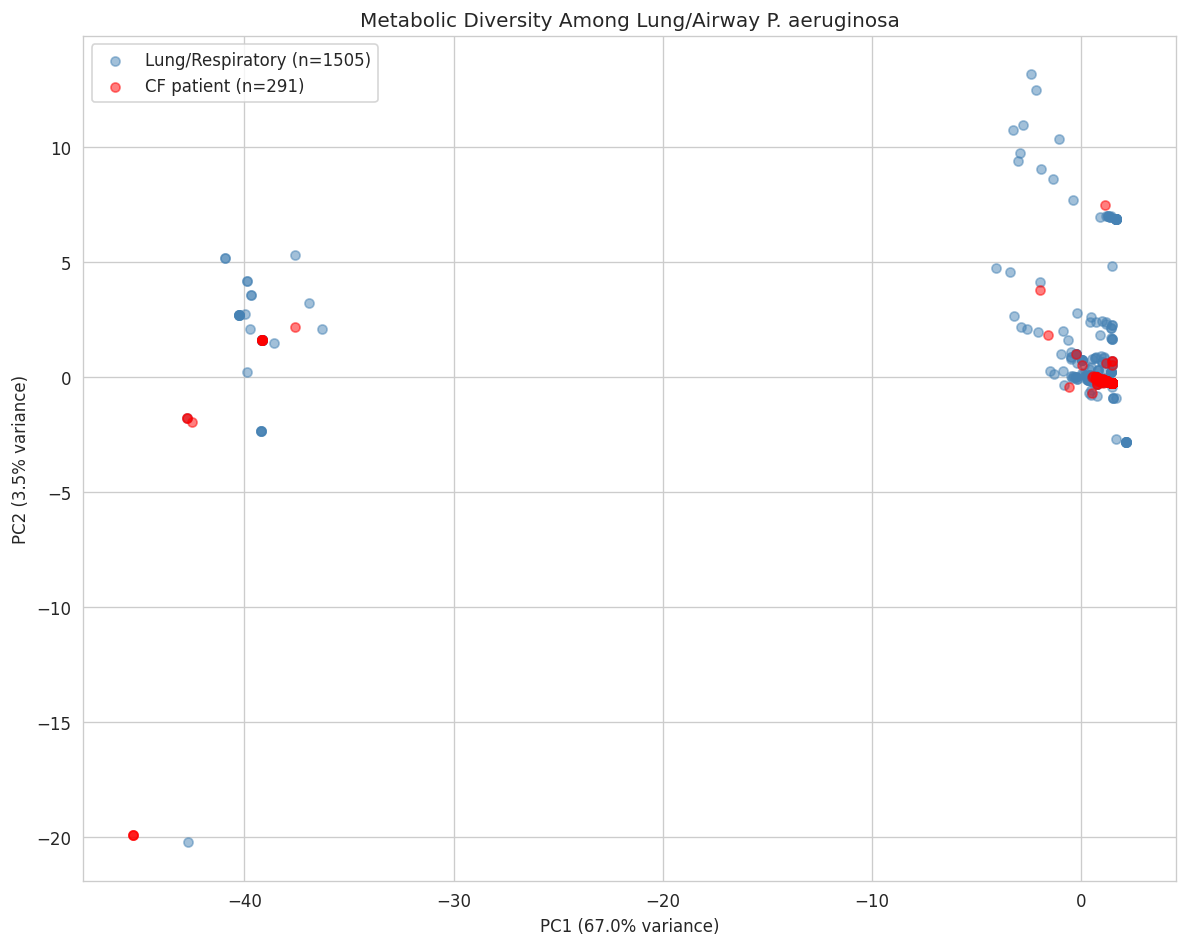

In [9]:
# Tag CF vs non-CF lung
# Match by stripping RS_/GB_ prefix from pa_env to match GapMind IDs in lung_pivot
gapmind_lung_ids = set(lung_cf.genome_id.unique())
gid_to_cat = {}
for _, row in pa_env.iterrows():
    stripped = row.genome_id[3:] if row.genome_id.startswith(('RS_','GB_')) else row.genome_id
    if stripped in gapmind_lung_ids:
        gid_to_cat[stripped] = row.category

lung_pivot['cf_status'] = [gid_to_cat.get(gid, 'Unknown') for gid in lung_pivot.index]
print(f'Category mapping: {pd.Series([gid_to_cat.get(gid, "Unknown") for gid in lung_pivot.index]).value_counts().to_dict()}')

fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {'CF patient': 'red', 'Lung/Respiratory': 'steelblue'}
for cat in ['Lung/Respiratory', 'CF patient']:
    mask = lung_pivot.cf_status == cat
    ax.scatter(coords[mask, 0], coords[mask, 1], alpha=0.5, s=30, 
              c=colors_map.get(cat, 'grey'), label=f'{cat} (n={mask.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Metabolic Diversity Among Lung/Airway P. aeruginosa')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '10_pa_lung_pca.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Disease Severity and PA Metabolic Activity (PROTECT Patients)

Using patient metatranscriptomics: which PA pathways are more active in sicker patients (status A=acute untreated) vs stable patients (status D)?

In [10]:
# Load PROTECT data
patients = pd.read_parquet(GOLD / 'dim_patient_sample.snappy.parquet')
kegg = pd.read_parquet(GOLD / 'fact_species_kegg_pathway_cpm.snappy.parquet')
metag = pd.read_parquet(GOLD / 'fact_metag_cpm.snappy.parquet')

# PA KEGG expression
pa_kegg = kegg[kegg.species == 'Pseudomonas aeruginosa'].copy()
pa_kegg['cpm'] = pd.to_numeric(pa_kegg['cpm'], errors='coerce')

# Extract sample IDs and match to patient status
# Sample names are like 'pro101_metag' or 'pro101_metars'
pa_kegg['sample_num'] = pa_kegg['sample'].str.extract(r'pro(\d+)', expand=False)
patients['sample_num'] = patients.sample_id.astype(str)
patients['status_letter'] = patients.patient_status.str[0]

# Map sample to patient status
sample_status = patients.set_index('sample_num')['status_letter'].to_dict()
pa_kegg['patient_status'] = pa_kegg.sample_num.map(sample_status)

pa_kegg_with_status = pa_kegg[pa_kegg.patient_status.notna()]
print(f'PA KEGG with patient status: {len(pa_kegg_with_status)} rows')
print(f'Status distribution: {pa_kegg_with_status.groupby("patient_status")["sample"].nunique().to_dict()}')

# PA abundance by status
metag['cpm'] = pd.to_numeric(metag['cpm'], errors='coerce')
pa_abund = metag[metag.species == 'Pseudomonas aeruginosa'].copy()
pa_abund['sample_num'] = pa_abund['sample'].str.extract(r'pro(\d+)', expand=False)
pa_abund['status'] = pa_abund.sample_num.map(sample_status)
pa_by_status = pa_abund[pa_abund.status.notna()].groupby('status')['cpm'].agg(['mean','median','count'])
print(f'\nPA abundance by patient status:')
print(pa_by_status.round(0).to_string())

PA KEGG with patient status: 20800 rows
Status distribution: {'A': 14, 'B': 36, 'C': 8, 'D': 42}

PA abundance by patient status:
            mean   median  count
status                          
A       187733.0    415.0      7
B        99081.0  10497.0     18
C        18013.0    341.0      4
D       228672.0     25.0     21


In [11]:
# Compare PA pathway expression: sick (A/B) vs stable (D)
sick = pa_kegg_with_status[pa_kegg_with_status.patient_status.isin(['A', 'B'])]
stable = pa_kegg_with_status[pa_kegg_with_status.patient_status == 'D']

sick_mean = sick.groupby('pathway')['cpm'].mean()
stable_mean = stable.groupby('pathway')['cpm'].mean()

pathway_comparison = pd.DataFrame({
    'sick_cpm': sick_mean,
    'stable_cpm': stable_mean
}).dropna()
pathway_comparison['log2fc'] = np.log2((pathway_comparison.sick_cpm + 1) / (pathway_comparison.stable_cpm + 1))
pathway_comparison['total_cpm'] = pathway_comparison.sick_cpm + pathway_comparison.stable_cpm

# Filter to pathways with meaningful expression
expressed = pathway_comparison[pathway_comparison.total_cpm > 10].sort_values('log2fc')

print(f'PA pathways compared (sick vs stable): {len(expressed)}')
print(f'\nMost UPREGULATED in sick patients (acute exacerbation):')
print(expressed.tail(10)[['sick_cpm','stable_cpm','log2fc']].round(2).to_string())
print(f'\nMost DOWNREGULATED in sick patients:')
print(expressed.head(10)[['sick_cpm','stable_cpm','log2fc']].round(2).to_string())

PA pathways compared (sick vs stable): 207

Most UPREGULATED in sick patients (acute exacerbation):
                                                                                                     sick_cpm  stable_cpm  log2fc
pathway                                                                                                                          
PilS-PilR (type 4 fimbriae synthesis) two-component regulatory system [PATH:map02020] [BR:ko02022]      21.57       32.68   -0.58
NarX-NarL (nitrate respiration) two-component regulatory system [PATH:map02020] [BR:ko02022]             7.57       11.53   -0.55
Microcin C transport system [PATH:map02010] [BR:ko02000]                                                15.69       21.29   -0.42
Glucuronate pathway (uronate pathway) [PATH:map00040]                                                  106.84      142.79   -0.42
Lipopolysaccharide biosynthesis, inner core => outer core => O-antigen [PATH:map00540]                  15.69       20.7

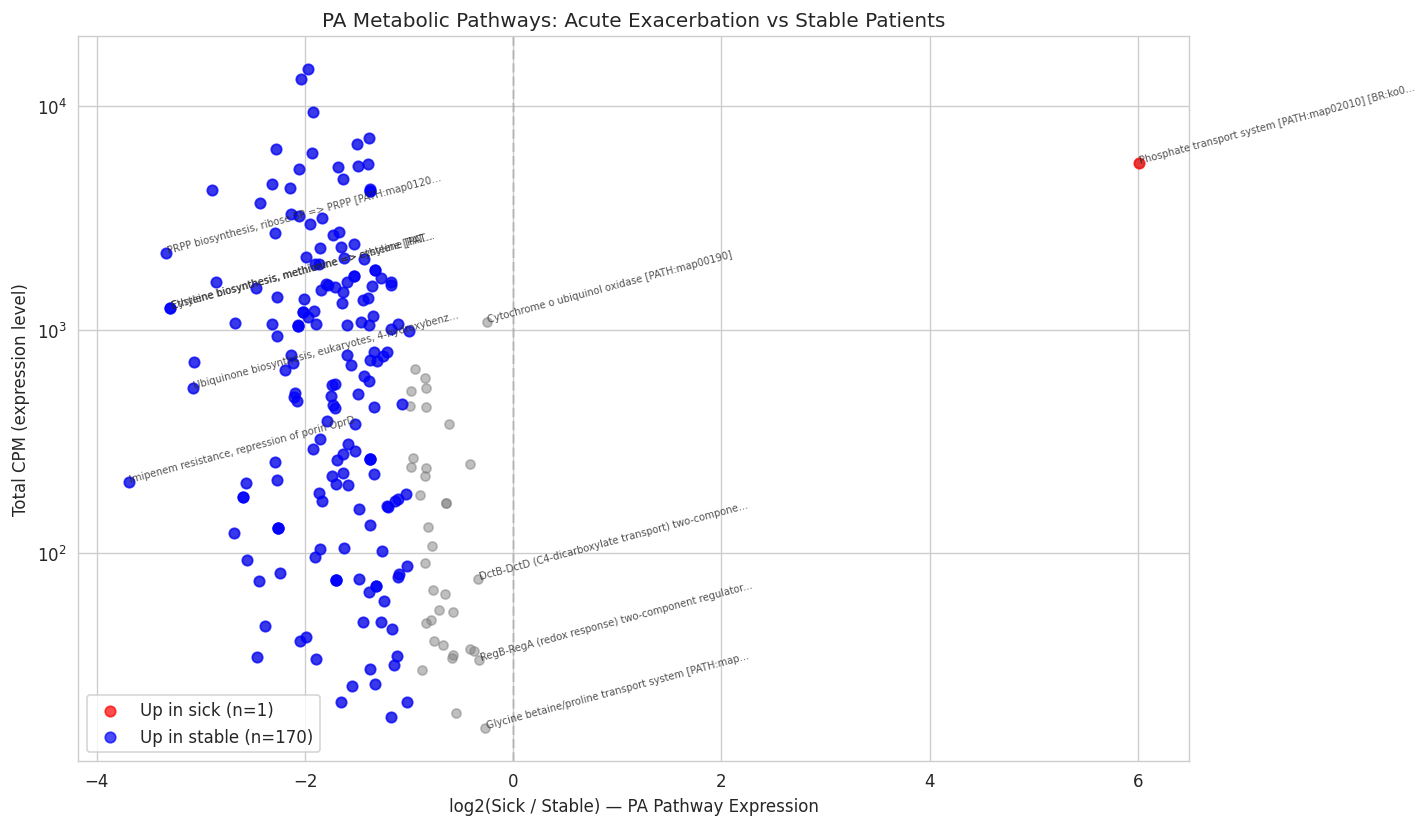

In [12]:
# Volcano-style plot: PA pathway expression sick vs stable
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(expressed.log2fc, expressed.total_cpm, alpha=0.5, s=30, c='grey')

# Highlight extreme pathways
up = expressed[expressed.log2fc > 1]
down = expressed[expressed.log2fc < -1]
ax.scatter(up.log2fc, up.total_cpm, alpha=0.7, s=40, c='red', label=f'Up in sick (n={len(up)})')
ax.scatter(down.log2fc, down.total_cpm, alpha=0.7, s=40, c='blue', label=f'Up in stable (n={len(down)})')

# Label top pathways
for idx in expressed.nlargest(5, 'log2fc').index:
    label = idx[:50] + '...' if len(idx) > 50 else idx
    ax.annotate(label, (expressed.loc[idx, 'log2fc'], expressed.loc[idx, 'total_cpm']),
               fontsize=6, alpha=0.8, rotation=15)
for idx in expressed.nsmallest(5, 'log2fc').index:
    label = idx[:50] + '...' if len(idx) > 50 else idx
    ax.annotate(label, (expressed.loc[idx, 'log2fc'], expressed.loc[idx, 'total_cpm']),
               fontsize=6, alpha=0.8, rotation=15)

ax.axvline(0, color='grey', ls='--', alpha=0.3)
ax.set_xlabel('log2(Sick / Stable) — PA Pathway Expression')
ax.set_ylabel('Total CPM (expression level)')
ax.set_title('PA Metabolic Pathways: Acute Exacerbation vs Stable Patients')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '10_pa_sick_vs_stable_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Implications for Formulation Design

In [13]:
# Save results
sig_df.to_csv(DATA / 'pa_lung_vs_nonlung_pathways.tsv', sep='\t', index=False)
expressed.to_csv(DATA / 'pa_sick_vs_stable_pathways.tsv', sep='\t')
pa_env.to_csv(DATA / 'pa_genome_sources.tsv', sep='\t', index=False)

print('=' * 60)
print('NB10 SUMMARY')
print('=' * 60)
print(f'PA genomes analyzed: {pa_env.genome_id.nunique()} (pangenome)')
print(f'  Lung/Respiratory: {len(lung_ids)}')
print(f'  CF-specific: {(pa_env.category == "CF patient").sum()}')
print(f'  Environmental: {len(env_ids)}')
print(f'\nLung vs non-lung pathways:')
print(f'  Significant at FDR<0.05: {(sig_df.q_value < 0.05).sum()}')
print(f'  Significant at FDR<0.10: {(sig_df.q_value < 0.10).sum()}')
print(f'\nPA expression in PROTECT patients:')
print(f'  Pathways upregulated in sick: {len(up)}')
print(f'  Pathways upregulated in stable: {len(down)}')
print(f'\nDesign implications:')
print(f'  Lung PA metabolic adaptations reveal which substrates are most')
print(f'  critical for competition in the actual disease context.')
print(f'  Pathways upregulated during acute exacerbation are high-priority')
print(f'  targets for competitive exclusion.')

print(f'\nFiles saved:')
print(f'  {DATA}/pa_lung_vs_nonlung_pathways.tsv')
print(f'  {DATA}/pa_sick_vs_stable_pathways.tsv')
print(f'  {DATA}/pa_genome_sources.tsv')

NB10 SUMMARY
PA genomes analyzed: 5199 (pangenome)
  Lung/Respiratory: 1796
  CF-specific: 291
  Environmental: 370

Lung vs non-lung pathways:
  Significant at FDR<0.05: 7
  Significant at FDR<0.10: 7

PA expression in PROTECT patients:
  Pathways upregulated in sick: 1
  Pathways upregulated in stable: 170

Design implications:
  Lung PA metabolic adaptations reveal which substrates are most
  critical for competition in the actual disease context.
  Pathways upregulated during acute exacerbation are high-priority
  targets for competitive exclusion.

Files saved:
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pa_lung_vs_nonlung_pathways.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pa_sick_vs_stable_pathways.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pa_genome_sources.tsv
